# Cambios del Script $22/06/26$
- ### Se agrega un Ansatz con la condicion inicial
- ### Dado el Ansatz se quita $Loss_{ic}$
- ### Cinco Capas ocultas con 72 neuronas y SWISH cada una  

In [ ]:
# ============================================================
# PINN para lahar por etapas (z_b fijo, sin Exner)
# Aprende: h, u, v, C, p
# ============================================================
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, optimizers #type: ignore
import matplotlib.pyplot as plt
tf.random.set_seed(7)
np.random.seed(7)

2026-09-20 18:19:30.162549: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-20 18:19:31.561728: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/djara/miniconda3/envs/tf216/lib/python3.11/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
# ============================================================
# SELECCIÓN DE TOPOGRAFÍA
# ============================================================
TOPO_SCENARIO = 2 # 1: plano inclinado, 2: valle gaussiano, 3: canal sinuoso
# ============================================================
# 1) PARÁMETROS FÍSICOS
# ============================================================
g = 9.81
rho_m = 1800.0
mu0 = 0.20
alpha_C = 1.2
alpha_p = 4.0
C0 = 0.45
p_ref = 1e4
kappa_C = 0.0 #5.0
tau_C = 1e9 # relajación casi nula para C
tau_p = 120.0
chi_p = 0.8 #0.35
u_star = 1.0
C_star = 0.05
eps_u = 1e-3
eps_h = 1e-6
# ============================================================
# 2) DOMINIO
# ============================================================
Lx = 10_000.0
Ly = 2_000.0
Tmax = 1200.0
x_min, x_max = 0.0, Lx
y_min, y_max = -Ly/2, Ly/2
t_min, t_max = 0.0, Tmax
# Normalización
x_scale = Lx
y_scale = Ly/2
t_scale = Tmax
h_scale = 10.0
u_scale = 10.0
p_scale = rho_m * g * h_scale

In [3]:
# ============================================================
# 3) TOPOGRAFÍA FIJA z_b(x,y)
# ============================================================
def zb0_physical(x, y):
    if TOPO_SCENARIO == 1:
        # Plano inclinado (Pendiente 10%) - Usar solo para calibrar
        Sx = 0.10
        z0 = 3000.0
        return z0 - Sx * x

    elif TOPO_SCENARIO == 2:
        # Valle Parabólico Suave (Aproximación Villarrica / Quebrada)
        Sx = 0.08         # Pendiente longitudinal (8%)
        z0 = 2900.0       # Altitud base
        
        # Curvatura del valle. 
        # A y=1000m, las paredes suben 50 metros respecto al centro.
        # Esto confina el flujo sin generar gradientes explosivos.
        k_y = 50.0 / (1000.0**2) 
        
        return (z0 - Sx * x) + k_y * (y**2)

    else:
        # Valle Convergente (Embudamiento)
        # El canal se hace más estrecho a medida que se desciende
        Sx = 0.08
        z0 = 2900.0
        # La pendiente transversal aumenta linealmente con 'x'
        k_y = (20.0 + 0.01 * x) / (1000.0**2) 
        return (z0 - Sx * x) + k_y * (y**2)

def grad_zb_fixed(x, y):
    """
    Gradiente de la topografía fija.
    Se calcula aparte para evitar NoneType en Graph mode.
    """
    with tf.GradientTape(persistent=True) as tape:
        tape.watch([x, y])
        zb = zb0_physical(x, y)
    zb_x = tape.gradient(zb, x)
    zb_y = tape.gradient(zb, y)
    del tape
    return zb_x, zb_y

# ============================================================
# 4) CONDICIONES INICIALES
# ============================================================
def ic_h_physical(x, y):
    x0, y0 = 1200.0, 0.0
    sigx, sigy = 900.0, 450.0
    h0 = 8.0
    return h0 * tf.exp(-((x - x0)**2 / (2 * sigx**2) + (y - y0)**2 / (2 * sigy**2)))

def ic_u_physical(x, y):
    return tf.zeros_like(x)

def ic_v_physical(x, y):
    return tf.zeros_like(y)

def ic_C_physical(x, y):
    C_bg = 0.35 #Minimo
    C_peak = 0.25
    x0, y0 = 1200.0, 0.0
    sigx, sigy = 1000.0, 550.0
    C = C_bg + C_peak * tf.exp(-((x - x0)**2 / (2 * sigx**2) + (y - y0)**2 / (2 * sigy**2)))
    return tf.clip_by_value(C, 0.2, 0.75)

def ic_p_physical(x, y):
    return 0.2 * rho_m * g * ic_h_physical(x, y)


# ============================================================
# 5) MUESTREO DE PUNTOS
# ============================================================
N_ic = 4000
N_pde = 30000
N_bc = 4000

# IC (t=0)
x_ic = tf.random.uniform((N_ic, 1), x_min, x_max, dtype=tf.float32)
y_ic = tf.random.uniform((N_ic, 1), y_min, y_max, dtype=tf.float32)
t_ic = tf.zeros_like(x_ic)

h_ic = ic_h_physical(x_ic, y_ic)
u_ic = ic_u_physical(x_ic, y_ic)
v_ic = ic_v_physical(x_ic, y_ic)
C_ic = ic_C_physical(x_ic, y_ic)
p_ic = ic_p_physical(x_ic, y_ic)

# PDE collocation
x_pde = tf.random.uniform((N_pde, 1), x_min, x_max, dtype=tf.float32)
y_pde = tf.random.uniform((N_pde, 1), y_min, y_max, dtype=tf.float32)
t_pde = tf.random.uniform((N_pde, 1), t_min, t_max, dtype=tf.float32)

# BC laterales
x_bc = tf.random.uniform((N_bc, 1), x_min, x_max, dtype=tf.float32)
t_bc = tf.random.uniform((N_bc, 1), t_min, t_max, dtype=tf.float32)
y_bc_top = tf.ones_like(x_bc) * y_max
y_bc_bot = tf.ones_like(x_bc) * y_min

y_bc = tf.random.uniform((N_bc, 1), y_min, y_max, dtype=tf.float32)
t_bc_x = tf.random.uniform((N_bc, 1), t_min, t_max, dtype=tf.float32)
x_bc_left  = tf.ones_like(y_bc) * x_min
x_bc_right = tf.ones_like(y_bc) * x_max

2026-09-20 18:19:36.636350: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-09-20 18:19:37.182009: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-09-20 18:19:37.182070: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-09-20 18:19:37.183648: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-09-20 18:19:37.183680: I external/local_xla/xla/stream_executor

In [4]:
# ============================================================
# 6) RED NEURONAL: (x,y,t) -> (h,u,v,C) (CON ANSATZ EXACTO)
# ============================================================
Cmax = 0.65

inputs = tf.keras.Input(shape=(3,))
x = layers.Dense(72, activation='swish')(inputs)
x = layers.Dense(72, activation='swish')(x)
x = layers.Dense(72, activation='swish')(x)
x = layers.Dense(72, activation='swish')(x)
x = layers.Dense(72, activation='swish')(x)
x = layers.Dense(72, activation='swish')(x)
out_raw = layers.Dense(5, activation='linear')(x)

model = tf.keras.Model(inputs=inputs, outputs=out_raw)

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=1e-3,
    decay_steps=3000,      
    decay_rate=0.85,        
    staircase=False
)
opt = tf.keras.mixed_precision.LossScaleOptimizer(tf.keras.optimizers.Adam(learning_rate=lr_schedule, clipnorm=1.0))

@tf.function
def predict_fields(xm, ym, tm):
    xn = xm / x_scale
    yn = ym / y_scale
    tn = tm / t_scale
    inp = tf.concat([xn, yn, tn], axis=1)
    raw = model(inp)

    h_raw = raw[:, 0:1]
    u_raw = raw[:, 1:2]
    v_raw = raw[:, 2:3]
    C_raw = raw[:, 3:4]
    p_raw = raw[:, 4:5]

    h0 = ic_h_physical(xm, ym)
    u0 = ic_u_physical(xm, ym)
    v0 = ic_v_physical(xm, ym)
    p0 = ic_p_physical(xm, ym)
    C0_ic = ic_C_physical(xm, ym)

    omega = 1.0 - tf.exp(-5.0 * tn)

    u = u0 + omega * (u_raw * u_scale)
    v = v0 + omega * (v_raw * u_scale)

    # Blindaje h: Evitar log(0)
    clip_h = tf.clip_by_value(1.0 - tf.exp(-h0), 1e-7, 1.0)
    inv_sp_h0 = h0 + tf.math.log(clip_h)
    h = tf.nn.softplus(inv_sp_h0 + omega * h_raw * h_scale)
    p = tf.nn.softplus(p_raw) * p_scale               # Pa

    # Blindaje C: Evitar log(0) con clip_by_value
    C0_norm = tf.clip_by_value(C0_ic / Cmax, 1e-7, 1.0 - 1e-7)
    inv_sig_C0 = tf.math.log(C0_norm / (1.0 - C0_norm))
    C = Cmax * tf.math.sigmoid(inv_sig_C0 + omega * C_raw)

    return h, u, v, C, p

In [5]:
# ============================================================
# 7) CIERRES FÍSICOS
# ============================================================
@tf.function
def mu_eff(C, p, h):
    denom = rho_m*g*h + p_ref
    return mu0*(1.0 + alpha_C*(C - C0)) * tf.exp(-alpha_p * (p/denom))

@tf.function
def cos_theta(zb_x, zb_y):
    return 1.0 / tf.sqrt(1.0 + zb_x**2 + zb_y**2)

@tf.function
def p_eq(h, C, u, v):
    speed = tf.sqrt(u**2 + v**2 + eps_u)
    phiC = C / (C + C_star)
    return chi_p * rho_m * g * h * phiC * (speed / (speed + u_star))

# ============================================================
# 8) RESIDUOS PDE (SIN Exner, z_b FIJO)
# ============================================================
@tf.function
def pde_residuals(xm, ym, tm):
    # Primer y segundo orden para h,u,v,C,p
    with tf.GradientTape(persistent=True) as tape2:
        tape2.watch([xm, ym, tm])
        with tf.GradientTape(persistent=True) as tape1:
            tape1.watch([xm, ym, tm])

            h, u, v, C, p = predict_fields(xm, ym, tm)
            zb = zb0_physical(xm, ym)
            H = h + zb
            hu = h * u
            hv = h * v

        # 1er orden
        h_t = tape1.gradient(h, tm)
        hu_x = tape1.gradient(hu, xm)
        hv_y = tape1.gradient(hv, ym)

        u_t = tape1.gradient(u, tm)
        u_x = tape1.gradient(u, xm)
        u_y = tape1.gradient(u, ym)

        v_t = tape1.gradient(v, tm)
        v_x = tape1.gradient(v, xm)
        v_y = tape1.gradient(v, ym)

        H_x = tape1.gradient(H, xm)
        H_y = tape1.gradient(H, ym)

        C_t = tape1.gradient(C, tm)
        C_x = tape1.gradient(C, xm)
        C_y = tape1.gradient(C, ym)

        p_t = tape1.gradient(p, tm)
        p_x = tape1.gradient(p, xm)
        p_y = tape1.gradient(p, ym)

    # 2do orden
    C_xx = tape2.gradient(C_x, xm)
    C_yy = tape2.gradient(C_y, ym)

    del tape1
    del tape2

    # Gradiente topografía fija (separado)
    zb_x, zb_y = grad_zb_fixed(xm, ym)

    # Seguridad extra por si alguna derivada sale None
    if C_xx is None:
        C_xx = tf.zeros_like(xm)
    if C_yy is None:
        C_yy = tf.zeros_like(ym)
    if zb_x is None:
        zb_x = tf.zeros_like(xm)
    if zb_y is None:
        zb_y = tf.zeros_like(ym)

    # (1) Masa
    S_h = 0.0
    f_mass = h_t + hu_x + hv_y - S_h

    # Fricción basal
    speed = tf.sqrt(u**2 + v**2 + eps_u)
    mu = mu_eff(C, p, h)
    cth = cos_theta(zb_x, zb_y)

    tau_b = mu * rho_m * g * h * cth
    tau_bx = tau_b * (u / (speed + eps_u))
    tau_by = tau_b * (v / (speed + eps_u))

    # (2) Momento x
    f_momx = u_t + u * u_x + v * u_y + g * H_x + tau_bx / (rho_m * (h + eps_h))

    # (3) Momento y
    f_momy = v_t + u * v_x + v * v_y + g * H_y + tau_by / (rho_m * (h + eps_h))

    # (4) Concentración
    C_eq_val = 0.45
    f_C = C_t + u * C_x + v * C_y - (kappa_C * (C_xx + C_yy) + (C_eq_val - C) / tau_C)
    
    # (5) Presión de poros (advección + relajación)
    peq = p_eq(h, C, u, v)
    f_p = p_t + u*p_x + v*p_y - (peq - p)/tau_p


    return f_mass, f_momx, f_momy, f_C, f_p



In [6]:
# ============================================================
# 9) PÉRDIDAS
# ============================================================
# ============================================================
# PÉRDIDA DE FRONTERA (NEUMANN / OPEN BOUNDARY)
# ============================================================

@tf.function
def neumann_C_residual(xb, yb, tb, direction):
    with tf.GradientTape() as tape:
        if direction == 'y':
            tape.watch(yb); _, _, _, C, _ = predict_fields(xb, yb, tb)  # FIX: C es el 4o, no el 5o
            dC_dn = tape.gradient(C, yb)
        else:
            tape.watch(xb); _, _, _, C, _ = predict_fields(xb, yb, tb)  # FIX: C es el 4o, no el 5o
            dC_dn = tape.gradient(C, xb)
    return dC_dn

@tf.function
def loss_bc():
    # --- h: Dirichlet en paredes laterales (igual que antes) ---
    h_top, _, _, _, _ = predict_fields(x_bc, y_bc_top, t_bc)
    h_bot, _, _, _, _ = predict_fields(x_bc, y_bc_bot, t_bc)

    eps = 1e-8
    loss_h_top = tf.reduce_mean(tf.square((h_top - 0.0) / (h_scale + eps)))
    loss_h_bot = tf.reduce_mean(tf.square((h_bot - 0.0) / (h_scale + eps)))

    # --- CORRECCIÓN: C con Neumann homogéneo en LAS 4 FRONTERAS ---
    # Paredes laterales del valle (y = y_min, y_max)
    dC_dy_top = neumann_C_residual(x_bc, y_bc_top, t_bc, 'y')
    dC_dy_bot = neumann_C_residual(x_bc, y_bc_bot, t_bc, 'y')
    # Entrada / salida longitudinal (x = x_min, x_max)
    dC_dx_left  = neumann_C_residual(x_bc_left,  y_bc, t_bc_x, 'x')
    dC_dx_right = neumann_C_residual(x_bc_right, y_bc, t_bc_x, 'x')

    # Escalas para adimensionalizar cada residuo de flujo (misma lógica
    # que scale_mass, scale_mom, scale_C en loss_pde_stage2). Se usa una
    # escala distinta para x e y porque Lx >> Ly y de lo contrario el
    # término en x quedaría sub-penalizado solo por la diferencia de escala
    # geométrica, no por ser realmente más preciso.
    scale_C_y = Cmax / y_scale
    scale_C_x = Cmax / x_scale


    return loss_h_top + loss_h_bot

@tf.function
def loss_pde_stage2(xb, yb, tb):
    f_mass, f_momx, f_momy, f_C, f_p = pde_residuals(xb, yb, tb)
    eps = 1e-8
    scale_mass = h_scale / t_scale
    scale_mom = u_scale / t_scale
    scale_C = Cmax / t_scale
    scale_p = p_scale / t_scale
    
    return (
        tf.reduce_mean(tf.square(f_mass / (scale_mass + eps))) +
        tf.reduce_mean(tf.square(f_momx / (scale_mom + eps))) +
        tf.reduce_mean(tf.square(f_momy / (scale_mom + eps))) +
        tf.reduce_mean(tf.square(f_C / (scale_C + eps))) +
        tf.reduce_mean(tf.square(f_p / (scale_p + eps)))
    )

@tf.function
def loss_pde_stage3(xb, yb, tb):
    return loss_pde_stage2(xb, yb, tb)


In [7]:
# ============================================================
# 10) ENTRENAMIENTO POR ETAPAS (Sin Etapa 1)
# ============================================================
pde_batch = 2048

# -------- ETAPA 2 (Ahora es tu inicio de entrenamiento) --------
epochs_stage2 = 5000
lambda_bc_2 = 50.0
lambda_pde_2 = 50.0

@tf.function
def train_step_stage2():
    idx = tf.random.uniform((pde_batch,), 0, N_pde, dtype=tf.int32)
    xb = tf.gather(x_pde, idx)
    yb = tf.gather(y_pde, idx)
    tb = tf.gather(t_pde, idx)

    with tf.GradientTape() as tape:
        Lbc = loss_bc()
        Lpde = loss_pde_stage2(xb, yb, tb)
        L = lambda_bc_2 * Lbc + lambda_pde_2 * Lpde
        
        # Escalamiento para LossScaleOptimizer
        scaled_loss = opt.scale_loss(L)
        
    scaled_grads = tape.gradient(scaled_loss, model.trainable_variables)
    opt.apply_gradients(zip(scaled_grads, model.trainable_variables))
    
    return L, Lbc, Lpde

print("\n==============================")
print("ETAPA 2: Ajuste de BC + Masa/Momento")
print("==============================")
for ep in range(epochs_stage2):
    L, Lbc, Lpde = train_step_stage2()
    if (ep + 1) % 100 == 0:
        print(f"[Stage 2] Epoch {ep+1}/{epochs_stage2} | Total {L.numpy():.3e} | BC {Lbc.numpy():.3e} | PDE {Lpde.numpy():.3e}")

# -------- ETAPA 3 --------
epochs_stage3 = 5000
lambda_bc_3 = 70.0
lambda_pde_3 = 100.0

@tf.function
def train_step_stage3():
    idx = tf.random.uniform((pde_batch,), 0, N_pde, dtype=tf.int32)
    xb = tf.gather(x_pde, idx)
    yb = tf.gather(y_pde, idx)
    tb = tf.gather(t_pde, idx)

    with tf.GradientTape() as tape:
        Lbc = loss_bc()
        Lpde = loss_pde_stage3(xb, yb, tb)
        L = lambda_bc_3 * Lbc + lambda_pde_3 * Lpde
        
        scaled_loss = opt.scale_loss(L)
        
    scaled_grads = tape.gradient(scaled_loss, model.trainable_variables)
    opt.apply_gradients(zip(scaled_grads, model.trainable_variables))
    
    return L, Lbc, Lpde

print("\n==============================")
print("ETAPA 3: BC + PDE Completas (Exigencia máxima)")
print("==============================")
for ep in range(epochs_stage3):
    L, Lbc, Lpde = train_step_stage3()
    if (ep + 1) % 100 == 0:
        print(f"[Stage 3] Epoch {ep+1}/{epochs_stage3} | Total {L.numpy():.3e} | BC {Lbc.numpy():.3e} | PDE {Lpde.numpy():.3e}")

print("\nEntrenamiento completado. ¡Tu Condición Inicial está intacta por construcción!")


ETAPA 2: Ajuste de BC + Masa/Momento
[Stage 2] Epoch 100/5000 | Total 9.696e+04 | BC 3.927e+01 | PDE 1.900e+03
[Stage 2] Epoch 200/5000 | Total 6.943e+04 | BC 2.787e+01 | PDE 1.361e+03
[Stage 2] Epoch 300/5000 | Total 5.785e+04 | BC 2.891e+01 | PDE 1.128e+03
[Stage 2] Epoch 400/5000 | Total 4.512e+04 | BC 3.268e+01 | PDE 8.697e+02
[Stage 2] Epoch 500/5000 | Total 2.802e+04 | BC 2.205e+01 | PDE 5.383e+02
[Stage 2] Epoch 600/5000 | Total 2.329e+04 | BC 1.359e+01 | PDE 4.523e+02
[Stage 2] Epoch 700/5000 | Total 2.683e+04 | BC 9.791e+00 | PDE 5.267e+02
[Stage 2] Epoch 800/5000 | Total 1.893e+04 | BC 7.073e+00 | PDE 3.715e+02
[Stage 2] Epoch 900/5000 | Total 1.756e+04 | BC 5.223e+00 | PDE 3.461e+02
[Stage 2] Epoch 1000/5000 | Total 1.807e+04 | BC 3.961e+00 | PDE 3.574e+02
[Stage 2] Epoch 1100/5000 | Total 1.544e+04 | BC 3.412e+00 | PDE 3.055e+02
[Stage 2] Epoch 1200/5000 | Total 1.635e+04 | BC 2.987e+00 | PDE 3.240e+02
[Stage 2] Epoch 1300/5000 | Total 1.560e+04 | BC 2.931e+00 | PDE 3.090e

Error máximo de la condición inicial:
  |h_real - h_PINN|_inf = 9.537e-07 m      OK (ansatz duro)
  |C_real - C_PINN|_inf = 1.192e-07        OK (ansatz duro)
  |p_real - p_PINN|_inf = 1.752e+04 Pa     <-- p NO TIENE ANSATZ DE IC: la condición inicial de presión de poros NO se está imponiendo

  lambda = p/(rho*g*h) en t=0:  min=0.224  mediana=293.281  max=2.252e+06
  lambda deseado por ic_p_physical: 0.200 (uniforme)
  fracción del dominio con lambda > 1 (físicamente imposible): 66.0%


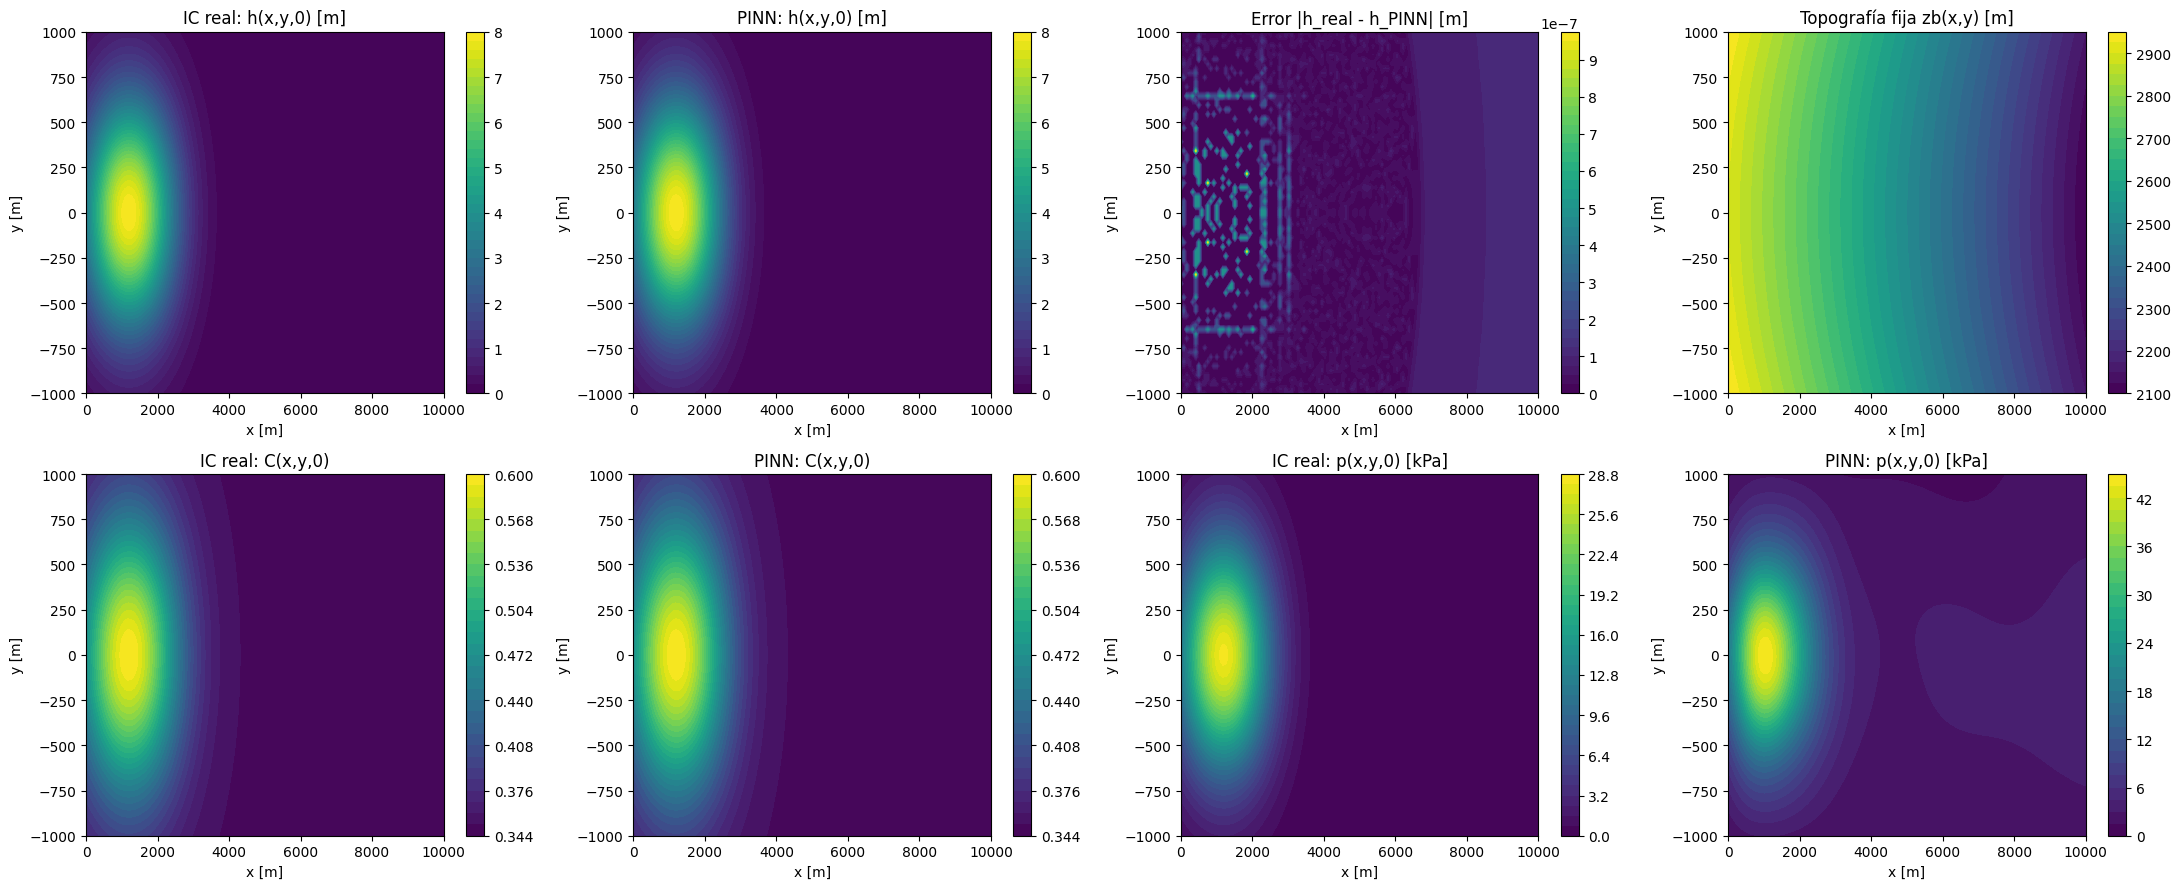

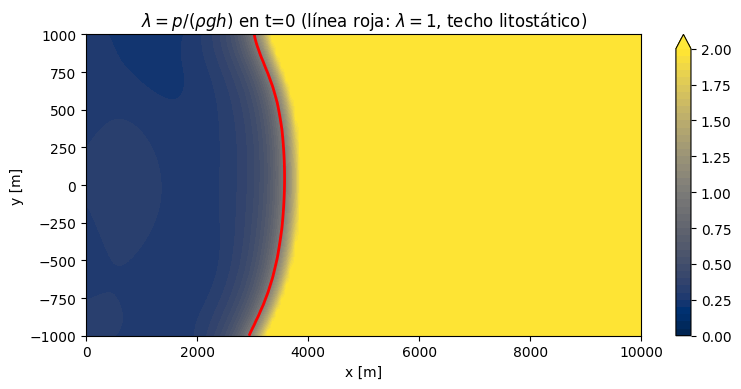

In [8]:
# ============================================================
# 11) VERIFICACIÓN DE CONDICIÓN INICIAL  (h, C y AHORA TAMBIÉN p)
# ============================================================
nx, ny = 120, 80
xg = np.linspace(x_min, x_max, nx).astype(np.float32)
yg = np.linspace(y_min, y_max, ny).astype(np.float32)
X, Y = np.meshgrid(xg, yg, indexing='xy')

Xf = X.reshape(-1, 1)
Yf = Y.reshape(-1, 1)
T0 = np.zeros_like(Xf, dtype=np.float32)

h_pred0, u_pred0, v_pred0, C_pred0, p_pred0 = predict_fields(
    tf.convert_to_tensor(Xf), tf.convert_to_tensor(Yf), tf.convert_to_tensor(T0))

h0_map_pred = h_pred0.numpy().reshape(ny, nx)
C0_map_pred = C_pred0.numpy().reshape(ny, nx)
p0_map_pred = p_pred0.numpy().reshape(ny, nx)
zb_map = zb0_physical(tf.convert_to_tensor(Xf), tf.convert_to_tensor(Yf)).numpy().reshape(ny, nx)

h0_map_true = ic_h_physical(tf.convert_to_tensor(Xf), tf.convert_to_tensor(Yf)).numpy().reshape(ny, nx)
C0_map_true = ic_C_physical(tf.convert_to_tensor(Xf), tf.convert_to_tensor(Yf)).numpy().reshape(ny, nx)
p0_map_true = ic_p_physical(tf.convert_to_tensor(Xf), tf.convert_to_tensor(Yf)).numpy().reshape(ny, nx)

lam0_map = p0_map_pred / np.maximum(rho_m * g * h0_map_pred, 1e-9)

# ------------------------------------------------------------
# CHEQUEO CUANTITATIVO. El ansatz hace EXACTAS las IC de h, u, v y C.
# Para p NO hay ansatz (p = softplus(p_raw)*p_scale), así que este error
# NO tiene por qué ser pequeño: es justamente el diagnóstico.
# ------------------------------------------------------------
err_h = np.abs(h0_map_true - h0_map_pred).max()
err_C = np.abs(C0_map_true - C0_map_pred).max()
err_p = np.abs(p0_map_true - p0_map_pred).max()
print("Error máximo de la condición inicial:")
print(f"  |h_real - h_PINN|_inf = {err_h:.3e} m      {'OK (ansatz duro)' if err_h < 1e-4 else '<-- REVISAR'}")
print(f"  |C_real - C_PINN|_inf = {err_C:.3e}        {'OK (ansatz duro)' if err_C < 1e-4 else '<-- REVISAR'}")
print(f"  |p_real - p_PINN|_inf = {err_p:.3e} Pa     "
      f"{'OK' if err_p < 1e3 else '<-- p NO TIENE ANSATZ DE IC: la condición inicial de presión de poros NO se está imponiendo'}")
print()
print(f"  lambda = p/(rho*g*h) en t=0:  min={lam0_map.min():.3f}  "
      f"mediana={np.median(lam0_map):.3f}  max={lam0_map.max():.3e}")
print(f"  lambda deseado por ic_p_physical: 0.200 (uniforme)")
print(f"  fracción del dominio con lambda > 1 (físicamente imposible): "
      f"{100.0*(lam0_map > 1.0).mean():.1f}%")

fig, axes = plt.subplots(2, 4, figsize=(22, 9))
panels = [
    (h0_map_true, "IC real: h(x,y,0) [m]", None),
    (h0_map_pred, "PINN: h(x,y,0) [m]", None),
    (np.abs(h0_map_true - h0_map_pred), "Error |h_real - h_PINN| [m]", None),
    (zb_map, "Topografía fija zb(x,y) [m]", None),
    (C0_map_true, "IC real: C(x,y,0)", None),
    (C0_map_pred, "PINN: C(x,y,0)", None),
    (p0_map_true / 1e3, "IC real: p(x,y,0) [kPa]", None),
    (p0_map_pred / 1e3, "PINN: p(x,y,0) [kPa]", None),
]
for ax, (Z, title, _) in zip(axes.ravel(), panels):
    cs = ax.contourf(X, Y, Z, levels=40)
    ax.set_title(title); ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
    plt.colorbar(cs, ax=ax)
plt.tight_layout(); plt.show()

# Mapa de lambda inicial: hace visible si p respeta el techo litostático
fig, ax = plt.subplots(figsize=(8, 4))
cs = ax.contourf(X, Y, np.clip(lam0_map, 0, 2), levels=np.linspace(0, 2, 41),
                 cmap='cividis', extend='max')
ax.contour(X, Y, lam0_map, levels=[1.0], colors='r', linewidths=2)
ax.set_title(r"$\lambda = p/(\rho g h)$ en t=0 (línea roja: $\lambda=1$, techo litostático)")
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
plt.colorbar(cs, ax=ax); plt.tight_layout(); plt.show()


   t [s]   x_centroide [m]   |u|_max [m/s]  lambda medio   h_max [m]  masa/masa(0)
       0            1351.2            0.00         0.403        7.99        1.0000
      50            1392.7           24.87         0.231        8.18        1.1775
     100            1323.1           28.15         0.106        9.11        1.3444
     150            1389.4           25.45         0.055       10.25        1.6224
     200            1513.8           22.61         0.035       11.27        1.9343
     250            1665.8           20.30         0.026       12.17        2.2774
     300            1822.3           18.18         0.021       13.02        2.6494
     350            1967.3           16.22         0.019       13.86        3.0412
     400            2094.1           14.49         0.018       14.69        3.4434
     450            2202.9           12.99         0.018       15.53        3.8483
     500            2296.6           11.71         0.019       16.35        4.2506
    

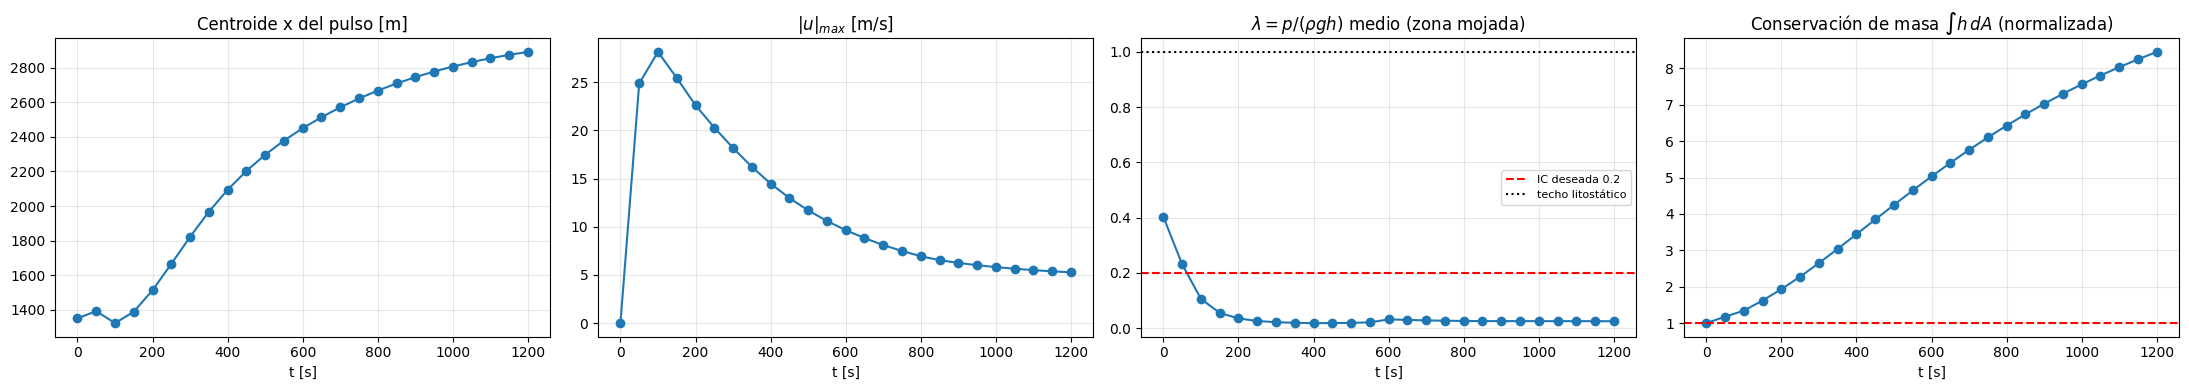

In [9]:
# ============================================================
# 12) DIAGNÓSTICO TEMPORAL: ¿se mueve el lahar y se conserva la masa?
# ============================================================
t_check = np.linspace(0.0, Tmax, 25)
cent, vmax_l, lam_c, mass, hmax_l = [], [], [], [], []
cell_area = (xg[1] - xg[0]) * (yg[1] - yg[0])

for tv in t_check:
    Tf = np.full_like(Xf, tv, dtype=np.float32)
    hp, up, vp, Cp, pp = predict_fields(
        tf.convert_to_tensor(Xf), tf.convert_to_tensor(Yf), tf.convert_to_tensor(Tf))
    hh = hp.numpy().ravel(); uu = up.numpy().ravel()
    vv = vp.numpy().ravel(); pz = pp.numpy().ravel()
    w = np.maximum(hh, 0.0)
    cent.append(float((Xf.ravel() * w).sum() / max(w.sum(), 1e-12)))
    vmax_l.append(float(np.sqrt(uu**2 + vv**2).max()))
    wet = hh > 0.1
    lam_c.append(float((pz[wet] / (rho_m * g * hh[wet])).mean()) if wet.any() else np.nan)
    mass.append(float(w.sum() * cell_area))
    hmax_l.append(float(hh.max()))

print(f"{'t [s]':>8} {'x_centroide [m]':>17} {'|u|_max [m/s]':>15} "
      f"{'lambda medio':>13} {'h_max [m]':>11} {'masa/masa(0)':>13}")
for k, tv in enumerate(t_check):
    print(f"{tv:8.0f} {cent[k]:17.1f} {vmax_l[k]:15.2f} {lam_c[k]:13.3f} "
          f"{hmax_l[k]:11.2f} {mass[k]/mass[0]:13.4f}")

desp = cent[-1] - cent[0]
print(f"\n>>> Desplazamiento del centroide en {Tmax:.0f} s: {desp:+.1f} m "
      f"(velocidad media {desp/Tmax:+.2f} m/s)")
print(f">>> Deriva de masa: {mass[-1]/mass[0]:.4f}  (debe ser 1.0000, ya que S_h = 0)")
print(f">>> lambda: {lam_c[0]:.3f} (t=0) -> {lam_c[-1]:.3f} (t={Tmax:.0f})")
if desp < 50.0:
    print("\n*** EL FLUJO SIGUE BLOQUEADO por fricción. ***")
if abs(mass[-1]/mass[0] - 1.0) > 0.05:
    print("*** LA MASA NO SE CONSERVA: el peso de f_mass en la pérdida es insuficiente. ***")

fig, axes = plt.subplots(1, 4, figsize=(22, 4))
axes[0].plot(t_check, cent, 'o-'); axes[0].set_title("Centroide x del pulso [m]")
axes[1].plot(t_check, vmax_l, 'o-'); axes[1].set_title(r"$|u|_{max}$ [m/s]")
axes[2].plot(t_check, lam_c, 'o-'); axes[2].axhline(0.2, ls='--', c='r', label='IC deseada 0.2')
axes[2].axhline(1.0, ls=':', c='k', label='techo litostático')
axes[2].set_title(r"$\lambda = p/(\rho g h)$ medio (zona mojada)"); axes[2].legend(fontsize=8)
axes[3].plot(t_check, np.array(mass)/mass[0], 'o-'); axes[3].axhline(1.0, ls='--', c='r')
axes[3].set_title(r"Conservación de masa $\int h\,dA$ (normalizada)")
for a in axes: a.set_xlabel("t [s]"); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()


In [10]:
# ============================================================
# 13) ANIMACIÓN: h, |u|, C, lambda
# ============================================================
import matplotlib.animation as animation
from IPython.display import HTML

# OJO: ya no hay condición de Neumann sobre C (loss_C_flux fue eliminado y
# kappa_C = 0). La única BC activa es h = 0 tipo Dirichlet en y = +-Ly/2.
etiqueta = f"5PDE_chi{chi_p:.2f}_kC{kappa_C:.1f}_T{Tmax:.0f}"
num_frames = 60
t_values = np.linspace(0.0, Tmax, num_frames)

# Niveles FIJOS. contourf con levels=<int> recalcula los niveles frame a frame
# a partir del rango de los datos e IGNORA vmin/vmax para elegirlos, así que
# la escala de color cambiaba en cada cuadro y la animación era engañosa.
lv_h   = np.linspace(0.0, 8.0, 41)
lv_u   = np.linspace(0.0, 20.0, 41)
lv_C   = np.linspace(0.2, Cmax, 41)
lv_lam = np.linspace(0.0, 1.5, 41)

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
fig.suptitle(f"Lahar 5-EDP — {Tmax:.0f} s — "
             rf"$\chi_p$={chi_p}, $\kappa_C$={kappa_C}, $\tau_p$={tau_p:.0f} s")

def update(frame):
    for a in axes.ravel(): a.clear()
    tv = t_values[frame]
    Tf = np.full_like(Xf, tv, dtype=np.float32)
    hp, up, vp, Cp, pp = predict_fields(
        tf.convert_to_tensor(Xf), tf.convert_to_tensor(Yf), tf.convert_to_tensor(Tf))

    h_map = hp.numpy().reshape(ny, nx)
    U_map = np.sqrt(up.numpy()**2 + vp.numpy()**2).reshape(ny, nx)
    C_map = Cp.numpy().reshape(ny, nx)
    lam_map = (pp.numpy() / np.maximum(rho_m * g * hp.numpy(), 1e-9)).reshape(ny, nx)

    # Máscara por ESPESOR, no por concentración: C vale ~0.35 de fondo en todo
    # el dominio, así que la máscara antigua (C < 0.01) no se activaba nunca.
    dry = h_map < 0.05
    U_m, C_m, lam_m = (np.ma.masked_where(dry, Z) for Z in (U_map, C_map, lam_map))

    for a in axes.ravel(): a.set_facecolor('lightgrey')
    axes[0, 0].contourf(X, Y, h_map, levels=lv_h, cmap='viridis', extend='max')
    axes[0, 0].set_title(f"Espesor h   t={tv:.0f} s   [m]")
    axes[0, 1].contourf(X, Y, U_m, levels=lv_u, cmap='magma', extend='max')
    axes[0, 1].set_title(f"Velocidad |u|   t={tv:.0f} s   [m/s]")
    axes[1, 0].contourf(X, Y, C_m, levels=lv_C, cmap='plasma', extend='both')
    axes[1, 0].set_title(f"Concentración C   t={tv:.0f} s")
    axes[1, 1].contourf(X, Y, lam_m, levels=lv_lam, cmap='cividis', extend='max')
    axes[1, 1].contour(X, Y, np.ma.masked_where(dry, lam_map), levels=[1.0],
                       colors='r', linewidths=1.5)
    axes[1, 1].set_title(rf"$\lambda = p/(\rho g h)$   t={tv:.0f} s   (rojo: $\lambda=1$)")
    for a in axes.ravel():
        a.set_xlabel("x [m]"); a.set_ylabel("y [m]")

print("Generando animación, por favor espera...")
ani = animation.FuncAnimation(fig, update, frames=num_frames, interval=100)
aniname = f"Prediccion {etiqueta}.gif"
ani.save(aniname, writer='pillow', fps=10)
print(f"GIF guardado como '{aniname}'")
plt.close()
display(HTML(ani.to_jshtml()))


Generando animación, por favor espera...
GIF guardado como 'Prediccion 5PDE_chi0.80_kC0.0_T1200.gif'


# Por hacer
- fijar el pulso en el centro del plot, 500,0
- agregar la dem
- comparar con el mapa del evento
- usar los primeros 100s
- usar valle gausiano